# This notebook aimed to implement color quantization algorithms and visualize their performance.

In [1]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
import time

# Wu algorithm and k-means clustering function

In [2]:
def quantize_image_kmeans(image_path, RMSE_THRESHOLD=4, max_colors=32, sample_size=10000):
    """
    Quantizes an image using K-Means on its main colors.
    Displays the RMSE curve as a function of K.
    Returns the final quantized image, intermediate image at best_k//2,
    and also the vectors of K and RMSE for external plotting.
    """
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    pixels = img_np.reshape(-1, 3)

    # Sampling for faster KMeans
    if len(pixels) > sample_size:
        idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[idx]
    else:
        pixels_sample = pixels

    best_img = None
    best_k = None
    best_labels = None
    rmse_list = []
    k_list = []
    quantized_imgs = {}

    for k in range(1, max_colors + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        kmeans.fit(pixels_sample)
        labels = kmeans.predict(pixels)
        quantized_pixels = kmeans.cluster_centers_[labels].astype(int)
        mse = np.mean((pixels - quantized_pixels) ** 2)
        rmse = np.sqrt(mse)
        rmse = 100 * rmse / 255  # Normalize RMSE to [0, 100]
        rmse_list.append(rmse)
        k_list.append(k)
        quantized_imgs[k] = Image.fromarray(quantized_pixels.reshape(img_np.shape).astype("uint8"))

        if rmse < RMSE_THRESHOLD:
            best_k = k
            best_img = quantized_pixels.reshape(img_np.shape)
            best_labels = labels
            break

    if best_img is None:
        best_img = quantized_pixels.reshape(img_np.shape)
        best_k = max_colors
        best_labels = labels

    quantized_img = Image.fromarray(best_img.astype("uint8"))

    # Intermediate image at best_k // 2
    intermediate_k = max(1, best_k // 2)
    intermediate_img = quantized_imgs[intermediate_k]

    # Return everything needed for external plotting
    return quantized_img, best_k, best_labels, intermediate_img, intermediate_k, k_list, rmse_list

def quantize_image_wu_rmse(image_path, NRMSE_THRESHOLD=3.5, max_colors=32, sample_size=10000):
    """
    Quantifies an image using Wu's algorithm, increasing n_colors until RMSE < threshold.
    Returns the quantized image, the palette, n_colors used, and the RMSE curve.
    """
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    pixels = img_np.reshape(-1, 3)

    nrmse_list = []
    k_list = []
    best_img = None
    best_palette = None
    best_k = None

    for n_colors in range(2, max_colors + 1):
        img_quant = img.quantize(colors=n_colors, method=Image.FASTOCTREE)
        img_quant_np = np.array(img_quant.convert("RGB"))
        quant_pixels = img_quant_np.reshape(-1, 3)
        if quant_pixels.shape != pixels.shape:
            quant_pixels = quant_pixels[:pixels.shape[0], :]
        mse = np.mean((pixels - quant_pixels) ** 2)
        rmse = np.sqrt(mse)
        nrmse = 100 * rmse / 255  # Normalize RMSE to [0, 100]
        nrmse_list.append(nrmse)
        k_list.append(n_colors)
        if nrmse < NRMSE_THRESHOLD:
            best_img = img_quant.convert("RGB")
            best_palette = np.array(img_quant.getpalette()[:n_colors*3]).reshape(-1, 3)
            best_k = n_colors
            break

    if best_img is None:
        best_img = img_quant.convert("RGB")
        best_palette = np.array(img_quant.getpalette()[:n_colors*3]).reshape(-1, 3)
        best_k = n_colors

    return best_img, best_palette, best_k, k_list, nrmse_list



# Visualization functions for the NRMSE error

In [16]:
def plot_rmse_vs_k(k_list, rmse_list):
    """
    Plots the RMSE curve as a function of K (number of clusters).
    """
    plt.figure(figsize=(8, 5))
    plt.plot(k_list, rmse_list, marker='o')
    plt.title("RMSE vs Number of Clusters (K)")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("RMSE (in % of 255)")
    plt.grid(True)
    plt.show()

def plot_rmse_vs_colors(k_list_wu, rmse_list_wu):
    """
    Plots the RMSE as a function of the number of colors for Wu's quantization.
    
    Args:
        k_list_wu (list or array): List of color counts (number of clusters/colors).
        rmse_list_wu (list or array): Corresponding RMSE values.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(k_list_wu, rmse_list_wu, marker='o', color='purple')
    plt.title("NRMSE vs Number of Colors (Wu Quantization)")
    plt.xlabel("Number of Colors")
    plt.ylabel("NRMSE")
    plt.grid(True)
    plt.show()

# Comparison of the two algorithms on an image

In [14]:
def plot_rmse_wu_kmeans(k_list_kmeans, rmse_list_kmeans, k_list_wu, rmse_list_wu):
    """
    Plots the RMSE curve as a function of K (number of clusters).
    """
    plt.figure(figsize=(8, 5))
    plt.plot(k_list_kmeans, rmse_list_kmeans, marker='o', label='K-Means')
    plt.plot(k_list_wu, rmse_list_wu, marker='o', label='Wu')
    plt.title("NRMSE vs Number of Clusters (K)")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("MRMSE")
    plt.grid(True)
    plt.legend()
    plt.show()

def compare_time_wu_kmeans(image_path, n_colors=32, sample_size=10000):
    """
    Compare the execution time of Wu's algorithm and K-Means for color quantization.
    """

    # Measure time for Wu's algorithm
    start_time = time.time()
    _, _, n_colors_wu, _, _ = quantize_image_wu_rmse(image_path)
    wu_time = time.time() - start_time
    print(f"Wu's algorithm time for {n_colors_wu} colors: {wu_time:.4f} seconds")

    # Measure time for K-Means
    start_time = time.time()
    _, n_colors, _, _, _, _, _ = quantize_image_kmeans(image_path)
    kmeans_time = time.time() - start_time
    print(f"K-Means time for up to {n_colors} colors: {kmeans_time:.4f} seconds")

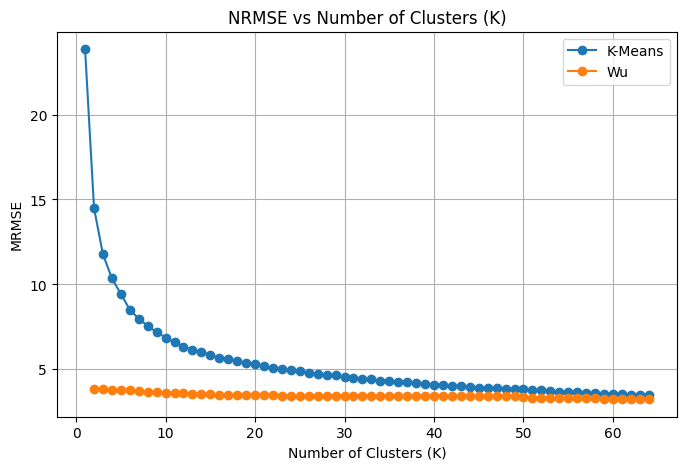

Wu's algorithm time for 17 colors: 0.3507 seconds
K-Means time for up to 32 colors: 2.2803 seconds


In [15]:
ssd_path = "/Volumes/PortableSSD/PDS_eugenie"
image_path = f"{ssd_path}/Fonds 2021/3-5 ans 2021/2021_3-5_0906_THA_R_C.jpg"
img = Image.open(image_path).convert("RGB")
quantized_img_wu, palette, n_colors_wu, k_list_wu, rmse_list_wu = quantize_image_wu_rmse(image_path, NRMSE_THRESHOLD=0.0001, max_colors=64)

quantized_img, best_k, best_labels, intermediate_img, intermediate_k, k_list, rmse_list = quantize_image_kmeans(image_path, RMSE_THRESHOLD=0.0001, max_colors=64)
plot_rmse_wu_kmeans(k_list, rmse_list, k_list_wu, rmse_list_wu)

compare_time_wu_kmeans(image_path, n_colors=32)

# Palette visualization function that can be used

In [ ]:
def plot_palette_colors(image, labels, n_colors):
    """
    Displays two plots:
    1. Number of pixels in the original image corresponding to each cluster.
    2. Image reconstructed and sampled by clusters.

    Arguments:
        image (PIL.Image): Original image
        labels (np.array): Cluster labels for each pixel
        n_colors (int): Number of colors/clusters
    """

    # Compute the size of each cluster
    counts = np.bincount(labels, minlength=n_colors)

    # Get the mean color of each cluster
    img_np = np.array(image)
    pixels = img_np.reshape(-1, 3)
    cluster_colors = np.array([pixels[labels == i].mean(axis=0) if np.any(labels == i) else [0,0,0] for i in range(n_colors)]).astype(int)

    # Reconstructed image (sampled)
    reconstructed_pixels = cluster_colors[labels].reshape(img_np.shape).astype(np.uint8)
    reconstructed_img = Image.fromarray(reconstructed_pixels)

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    ax[0].imshow(image)
    ax[0].axis('off')
    ax[0].set_title('Original Image')

    ax[1].bar(range(n_colors), counts, color=cluster_colors / 255.0)
    ax[1].set_title('Pixels per Cluster (Original Image)')
    ax[1].set_xlabel('Cluster')
    ax[1].set_ylabel('Number of Pixels')

    plt.tight_layout()
    plt.show()

def plot_color_histogram_compare(image_orig, image_quant):
    """
    Plots color histogram of original image (bars) and density curve 
    of quantized image for each channel (R, G, B).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde

    img_np_orig = np.array(image_orig).reshape(-1, 3)
    img_np_quant = np.array(image_quant).reshape(-1, 3)

    plt.figure(figsize=(12, 5))
    colors = ['r', 'g', 'b']
    labels = ['Red', 'Green', 'Blue']

    for i, (col, label) in enumerate(zip(colors, labels)):
        # Original histogram
        plt.hist(img_np_orig[:, i], bins=256, color=col, alpha=0.4, label=f"{label} original")
        # Quantized image density
        kde = gaussian_kde(img_np_quant[:, i])
        x = np.linspace(0, 255, 256)
        plt.plot(x, kde(x) * len(img_np_quant), color=col, linewidth=2, label=f"{label} quantized (curve)")

    plt.title("Color Histogram: Original (bars) vs Quantized (curve)")
    plt.xlabel("Color Intensity")
    plt.ylabel("Number of Pixels")
    plt.xlim([0, 256])
    plt.legend()
    plt.show()

# Illustrative plots on three randomly chosen images for Wu algorithm

Image 1:


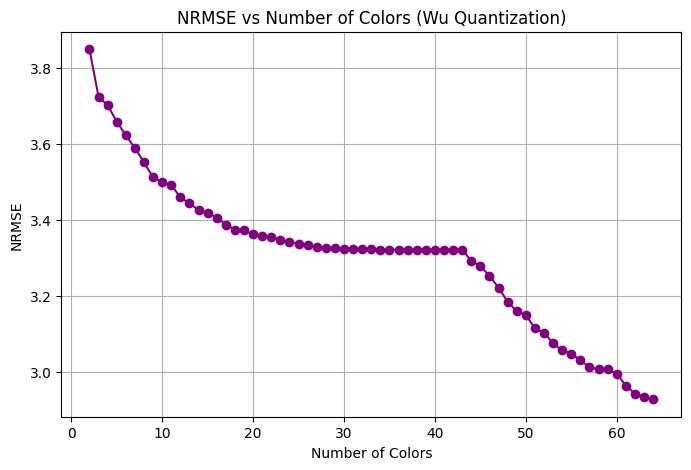

Image 2:


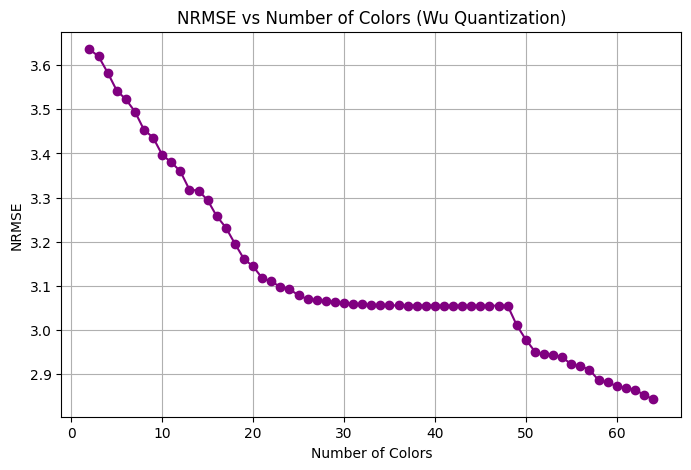

Image 3:


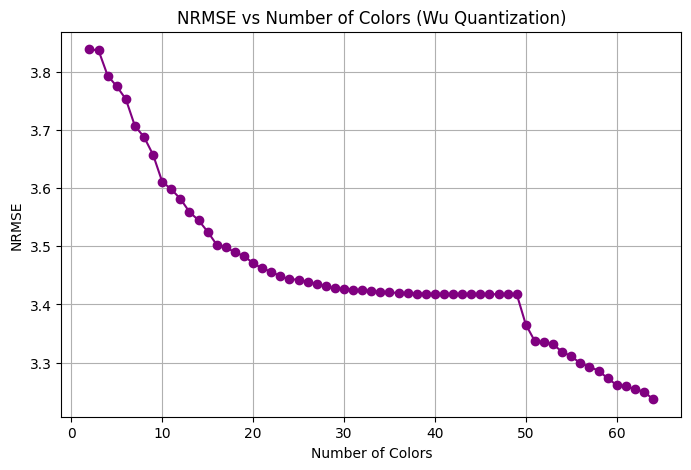

In [18]:
image_path = f"{ssd_path}/Fonds 2021/10-13 ans 2021/2021_10-13_0539_TWN_R_C.jpg"
image_path2 = f"{ssd_path}/Fonds 2021/10-13 ans 2021/2021_10-13_0548_CHI_R_C.jpg"
image_path3 = f"{ssd_path}/Fonds 2021/3-5 ans 2021/2021_3-5_0906_THA_R_C.jpg"

print("Image 1:")
quantized_img_wu, palette, n_colors_wu, k_list_wu, rmse_list_wu = quantize_image_wu_rmse(image_path, NRMSE_THRESHOLD=0.0001, max_colors=64)
plot_rmse_vs_colors(k_list_wu, rmse_list_wu)

print("Image 2:")
quantized_img_wu, palette, n_colors_wu, k_list_wu, rmse_list_wu = quantize_image_wu_rmse(image_path2, NRMSE_THRESHOLD=0.0001, max_colors=64)
plot_rmse_vs_colors(k_list_wu, rmse_list_wu)

print("Image 3:")
quantized_img_wu, palette, n_colors_wu, k_list_wu, rmse_list_wu = quantize_image_wu_rmse(image_path3, NRMSE_THRESHOLD=0.0001, max_colors=64)
plot_rmse_vs_colors(k_list_wu, rmse_list_wu)